## 2026_Winter_DL_week5_Homework
CNN 실습 예제코드입니다!

이번 5주차 숙제는 총 2가지로 구성되어 있습니다.
- 논문 리뷰 - ResNet : https://arxiv.org/abs/1512.03385
    - 다음 논문을 읽고 팀별로 논문 스터디 및 정리를 준비해주시면 됩니다! (notion 이나 ppt 로 논문 정리 자료 제작 후에 팀별로 git에 업로드 해주세요 :D)

- 코드 과제 (아래 두 가지 중 택1!)
    - 1) (CNN 을 처음 접해보시거나 기초를 더 다지고 싶은 분들께 추천)
        - 아래 실습코드를 그대로 참고하셔도 좋고, 새롭게 짜셔도 좋습니다. 데이터셋은 CIFAR10이 아닌 벤치마크(MNIST, FFHQ, ImageNet)이나 다른 데이터셋을 사용하되, 학습 시간 및 리소스를 적절히 사용할 수 있는 화질을 사용하는 것을 추천 드립니다. 또한, 앞서 배운 regularization, initialization, optimizer 등등 기법을 추가해보시거나, layer를 변형하는 시도를 추가하여 결과를 분석해주세요.
        - example : Earlystopping 추가, Dropoutlayer 추가, batch nomalization 추가, stride 및 padding 변형, Conv layer 추가 및 삭제 등등
    - 2) (이미 CNN 지식이 있는 분들)
        - ResNet 을 논문 "**만**" 읽고 핵심 모듈 코드를 직접 짜보세요! 코드를 보지 않고 conv block이나 layer들을 논문 기반으로 짜보시면 됩니다.(임교수님께서 추천해주신 공부법입니다 ㅎㅎ)

In [59]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data.dataloader import DataLoader
from torchvision import datasets, transforms
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm

## Data

100%|██████████| 342M/342M [00:21<00:00, 15.9MB/s]


Tensor의 크기: torch.Size([3, 224, 224])


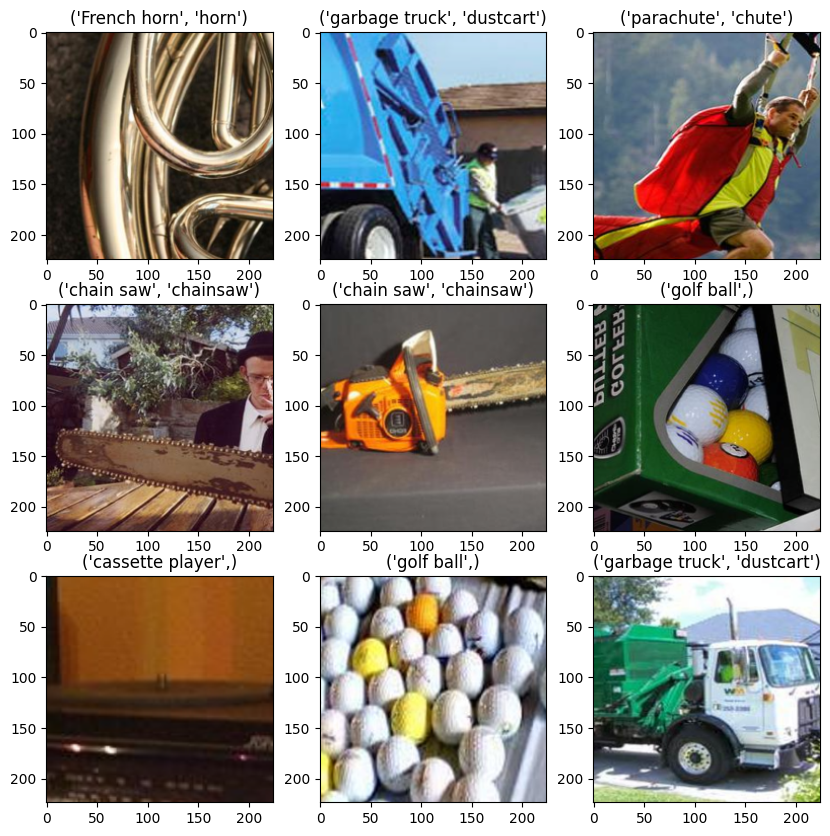

In [60]:
## 데이터셋 정의 -> ImageNet (Imagenette: class 10개)

# train data
train_data = datasets.Imagenette(
    root='./data',
    split='train',
    size='320px',
    download=True,
    ## data 전처리
    transform=transforms.Compose([
    # 이미지를 랜덤하게 resize 후 224x224로 crop
    transforms.RandomResizedCrop(224),
    # 50% 확률로 좌우 반전 -> 데이터 증강, overfitting 방지
    transforms.RandomHorizontalFlip(),
    # Image -> 3D Tensor & Scaling (0~1)
    transforms.ToTensor(),
    # ImageNet의 통계량으로 정규화
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])
)

# test data
test_data = datasets.Imagenette(
    root='./data',
    split='val', # test set으로 validation
    size='320px',
    download=True,
    transform=transforms.Compose([
        # 짧은 쪽을 256으로 리사이즈
        transforms.Resize(256),
        # 중앙 224x224 영역만 추출
        transforms.CenterCrop(224),
        # Tensor 변환, scaling
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485, 0.456, 0.406],
                             std=[0.229, 0.224, 0.225])
    ])
)


## 데이터 시각화

plt.figure(figsize=(10, 10))

import random
random_indices = random.sample(range(len(train_data)), 9)

for i, idx in enumerate(random_indices):
    img_tensor, label_idx = train_data[idx]
    # tensor [C, H, W] -> Image [H, W, C]
    img_show = img_tensor.permute(1, 2, 0).numpy()
    # 정규화 해제
    img_show = img_show * np.array([0.229, 0.224, 0.225]) + np.array([0.485, 0.456, 0.406])
    img_show = np.clip(img_show, 0, 1) # 0~1

    plt.subplot(3, 3, i+1)
    plt.imshow(img_show)
    plt.title(train_data.classes[label_idx])

# 이미지 한 장의 텐서 크기 출력 (3, 224, 224)
print(f"Tensor의 크기: {img_tensor.shape}")
plt.show()

## Modeling

In [61]:
## Block with shortcut for ResNet

class ResBlock(nn.Module):
    expansion = 1

    def __init__(self, in_channels, out_channels, stride=1, downsample=None):
        super(ResBlock, self).__init__()

        self.conv1 = nn.Conv2d(in_channels, out_channels,
                               kernel_size=3, stride=stride,
                               padding=1, bias=False)
        self.bn1 = nn.BatchNorm2d(out_channels)
        self.relu = nn.ReLU(inplace=True)

        self.conv2 = nn.Conv2d(out_channels, out_channels,
                               kernel_size=3, stride=1,
                               padding=1, bias=False)
        self.bn2 = nn.BatchNorm2d(out_channels)

        self.downsample = downsample

    def forward(self, x):
        identity = x

        out = self.conv1(x)
        out = self.bn1(out)
        out = self.relu(out)

        out = self.conv2(out)
        out = self.bn2(out)

        if self.downsample is not None:
            identity = self.downsample(x)

        out += identity
        out = self.relu(out)

        return out

In [ ]:
## ResNet 정의

class ResNet(nn.Module):
    def __init__(self, layers, num_classes=10):
        super(ResNet, self).__init__()
        self.in_channels = 64

        # 1. 7x7 Conv with Stride 2
        self.conv1 = nn.Conv2d(3, 64, kernel_size=7, stride=2, padding=3, bias=False)
        self.bn1 = nn.BatchNorm2d(64)
        self.relu = nn.ReLU(inplace=True)
        self.maxpool = nn.MaxPool2d(kernel_size=3, stride=2, padding=1)

        # 2. ResNet의 Stage 4개
        self.layer1 = self._make_layer(ResBlock, 64,  layers[0], stride=1)
        self.layer2 = self._make_layer(ResBlock, 128, layers[1], stride=2)
        self.layer3 = self._make_layer(ResBlock, 256, layers[2], stride=2)
        self.layer4 = self._make_layer(ResBlock, 512, layers[3], stride=2)

        # 3. Global Average Pooling & Fully-Connected Layer
        self.avgpool = nn.AdaptiveAvgPool2d((1, 1))
        self.fc = nn.Linear(512 * ResBlock.expansion, num_classes)

        self._initialize_weights()

    def _make_layer(self, block, out_channels, blocks, stride):
        downsample = None

        # Shortcut Connection
        if stride != 1 or self.in_channels != out_channels * block.expansion:
             # 이미지 size가 줄어들거나, channel 수가 변해 identity shortcut과 out의 dimension이 안 맞을 때
            downsample = nn.Sequential(
                nn.Conv2d(self.in_channels, out_channels * block.expansion,
                          kernel_size=1, stride=stride, bias=False),
                nn.BatchNorm2d(out_channels * block.expansion),
            )
             # 1x1 Convolution을 통해 downsampling

        layers = []
        # 첫 번째 블록 (size, channel 변경)
        layers.append(block(self.in_channels, out_channels, stride, downsample))
        self.in_channels = out_channels * block.expansion
        # 나머지 블록들 (유지)
        for _ in range(1, blocks):
            layers.append(block(self.in_channels, out_channels))

        return nn.Sequential(*layers)

    def forward(self, x):
        x = self.conv1(x)
        x = self.bn1(x)
        x = self.relu(x)
        x = self.maxpool(x)

        x = self.layer1(x)
        x = self.layer2(x)
        x = self.layer3(x)
        x = self.layer4(x)

        x = self.avgpool(x)
        x = torch.flatten(x, 1)
        x = self.fc(x)
        return x
    
    # 가중치 초기화
    def _initialize_weights(self):
        for m in self.modules():
             # Conv2d Layer 가중치를 Relu 함수에 적합하게 Kaiming Normal 초기화
            if isinstance(m, nn.Conv2d):
                nn.init.kaiming_normal_(m.weight, mode='fan_out', nonlinearity='relu')
             #  BN (1,0) 초기화
            elif isinstance(m, nn.BatchNorm2d):
                nn.init.constant_(m.weight, 1)
                nn.init.constant_(m.bias, 0)
             # FC Layer 가중치를 Kaiming Normal 초기화
            elif isinstance(m, nn.Linear):
                nn.init.kaiming_normal_(m.weight, mode='fan_out', nonlinearity='relu')
                nn.init.constant_(m.bias, 0)

        for m in self.modules():
             # ResBlock의 마지막 BN을 0으로 초기화 -> identity mapping
            if isinstance(m, ResBlock):
                nn.init.constant_(m.bn2.weight, 0)

## Training & Evaluation

In [63]:
# 데이터로더 정의
train_loader = DataLoader(train_data, batch_size=64, shuffle=True)
test_loader = DataLoader(test_data, batch_size=64, shuffle=False)

# 학습을 진행할 프로세서 설정
if torch.backends.mps.is_available():
    device = torch.device("mps")
elif torch.cuda.is_available():
    device = torch.device("cuda")
else:
    device = torch.device("cpu")

print(f"device 정보: {device}")

ResNet34 = ResNet([3, 4, 6, 3], num_classes=10)
ResNet34 = ResNet34.to(device)


device 정보: cuda


In [64]:
criterion = nn.CrossEntropyLoss()
optimizer = optim.SGD(ResNet34.parameters(), lr=0.1, momentum=0.9, weight_decay=0.0001)
scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=30, gamma=0.1)

# Training & Test
for epoch in range(50):
    ResNet34.train()
    running_loss = 0.0
    correct = 0
    total = 0

    for data, label in tqdm(train_loader):
        data, label = data.to(device), label.to(device)
        optimizer.zero_grad()
        preds = ResNet34(data)
        loss = criterion(preds, label)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()
        _, predicted = preds.max(1)
        total += label.size(0)
        correct += predicted.eq(label).sum().item()

    scheduler.step()

    if epoch == 0 or epoch % 10 == 9:
        ResNet34.eval()
        test_correct = 0
        test_total = 0

        with torch.no_grad():
            for data, label in test_loader:
                data, label = data.to(device), label.to(device)
                outputs = ResNet34(data)
                _, predicted = outputs.max(1)
                test_total += label.size(0)
                test_correct += predicted.eq(label).sum().item()

        test_acc = 100. * test_correct / test_total
        avg_loss = running_loss / len(train_loader)
        train_acc = 100. * correct / total

        print(f"Epoch {epoch+1} | Train Acc: {train_acc:.2f}% | Test Acc: {test_acc:.2f}% | Loss: {avg_loss:.4f}")

torch.save(ResNet34.state_dict(), "ResNet34.pth")

100%|██████████| 148/148 [01:24<00:00,  1.75it/s]


Epoch 1 | Train Acc: 32.44% | Test Acc: 43.87% | Loss: 2.3530


100%|██████████| 148/148 [01:26<00:00,  1.70it/s]


Epoch 10 | Train Acc: 71.33% | Test Acc: 73.76% | Loss: 0.8896


100%|██████████| 148/148 [01:26<00:00,  1.71it/s]


...

Epoch 30 | Train Acc: 82.74% | Test Acc: 80.84% | Loss: 0.5386


100%|██████████| 148/148 [01:27<00:00,  1.69it/s]


Epoch 40 | Train Acc: 89.46% | Test Acc: 89.25% | Loss: 0.3371


100%|██████████| 148/148 [01:27<00:00,  1.70it/s]


Epoch 50 | Train Acc: 90.57% | Test Acc: 89.68% | Loss: 0.2968
